In [29]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

backtest_data = '../../data/backtest/backtest_results_20250101_20261204.csv'
df = pd.read_csv(backtest_data)
df.columns

/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2842964580.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(backtest_data)


Index(['date', 'scode', 'Future_High_Tac', 'Future_Low_Tac',
       'Future_Close_Tac', 'Future_High_Str', 'Future_Low_Str',
       'Future_Close_Str', 'scores_GANDALF_target_str_gauss_rank',
       'scores_GANDALF_target_tac_gauss_rank',
       'scores_LightGBM_target_str_gauss_rank',
       'scores_LightGBM_target_str_triple_barrier',
       'scores_LightGBM_target_tac_gauss_rank',
       'scores_LightGBM_target_tac_tb_strategy_a',
       'scores_TCN_target_tac_vol_scaled_residual',
       'scores_TabNet_target_str_gauss_rank',
       'scores_TabNet_target_tac_gauss_rank'],
      dtype='object')

In [31]:

def evaluate_model_performance(df, score_col, target_col, n_bins=5, horizon=5, save_dir=None):
    """
    Rank ICの算出およびクオンタイル分析を実行する
    Args:
        df (pd.DataFrame): 'date', 'scode', score_col, target_col を含むDF
        score_col (str): モデルの予測スコア列名
        target_col (str): リターン（価格比）の列名 (例: Future_Close_Tac)
        n_bins (int): クオンタイル分割数
        horizon (int): 予測期間 (5 or 60)
        save_dir (str, optional): グラフを保存するディレクトリのパス
    Returns:
        pd.DataFrame: 日付ごとの対象件数、daily_ic、各クオンタイルの累積リターンを含む明細データフレーム
    """
    df = df[['date', 'scode', score_col, target_col]].dropna(subset=[score_col, target_col]).copy()
    # 前処理: リターンをログリターンに変換
    df['log_return'] = np.log(df[target_col])
    # Rank IC の算出 
    print(f"📊 Calculating Rank IC for {score_col}...")
    def calc_daily_ic(group):
        # スピアマンの順位相関係数
        ic, _ = stats.spearmanr(group[score_col], group['log_return'])
        return ic
    daily_ic = df.groupby('date').apply(calc_daily_ic)
    mean_ic = daily_ic.mean()
    icir = daily_ic.mean() / daily_ic.std()
    t_stat, p_value = stats.ttest_1samp(daily_ic.dropna(), 0)
    print(f"  Mean IC: {mean_ic:.4f}")
    print(f"  ICIR:    {icir:.4f}")
    print(f"  t-stat:  {t_stat:.4f} (p-value: {p_value:.4f})")
    
    # クオンタイル分析
    print(f"📈 Calculating Quantile Analysis (bins={n_bins})...")
    # 日次でスコアに基づきグループ分け (0: 最弱, n_bins-1: 最強)
    df['quantile'] = df.groupby('date')[score_col].transform(
        lambda x: pd.qcut(x, n_bins, labels=False, duplicates='drop')
    )
    # グループごとの日次平均ログリターン
    # 各スコアリング日時点での「その後のn日間のリターン」の平均
    daily_group_ret = df.groupby(['date', 'quantile'])['log_return'].mean().unstack()
    # 累積ログリターンの算出
    # 予測期間の重複（オーバーラップ）を考慮し、horizonで割ることで1日あたりの期待値に補正
    cum_log_ret = daily_group_ret.cumsum() / horizon
    
    # --- 4. 可視化 ---
    daily_count = df.groupby('date').size().rename('target_count')
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
    # ICの推移
    daily_ic.rolling(window=20).mean().plot(ax=ax1, color='tab:blue', alpha=0.8)
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.set_title(f"Rank IC (20-day Rolling Mean) - {score_col}")
    ax1.set_ylabel("IC")
    # 累積リターンの推移
    for i in range(n_bins):
        label = f"Q{i+1} (Top)" if i == n_bins-1 else f"Q{i+1}"
        cum_log_ret[i].plot(ax=ax2, label=label, linewidth=2)
    ax2.set_title(f"Cumulative Log Returns by Quantile (Scaled by {horizon}d)")
    ax2.set_ylabel("Cumulative Log Return")
    ax2.legend(loc='upper left')
    ax2.grid(axis='y', alpha=0.3)
    # 対象件数と生ICの推移
    ax3.bar(daily_count.index, daily_count.values, color='tab:gray', alpha=0.3, width=1.0, label='Target Count')
    ax3.set_ylabel("Target Count")
    ax3.set_title(f"Raw Rank IC and Target Count - {score_col}")
    ax3_twin = ax3.twinx()
    ax3_twin.plot(daily_ic.index, daily_ic.values, color='tab:red', alpha=0.6, linewidth=1, label='Raw Rank IC')
    ax3_twin.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax3_twin.set_ylabel("Raw Rank IC")
    
    lines_1, labels_1 = ax3.get_legend_handles_labels()
    lines_2, labels_2 = ax3_twin.get_legend_handles_labels()
    ax3.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"evaluation_{score_col}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✅ Plot saved to {save_path}")
    plt.show()

    # --- 5. 結果の結合と返却 ---
    daily_ic.name = 'daily_ic'
    cum_log_ret_renamed = cum_log_ret.copy()
    cum_log_ret_renamed.columns = [f'cum_log_ret_Q{i+1}' for i in range(n_bins)]
    result_df = pd.concat([daily_count, daily_ic, cum_log_ret_renamed], axis=1).reset_index()
    return result_df

📊 Calculating Rank IC for scores_GANDALF_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic, _ = stats.spearmanr(group[score_col], group['log_return'])
/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0366
  ICIR:    0.1677
  t-stat:  2.7503 (p-value: 0.0064)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_GANDALF_target_tac_gauss_rank.png


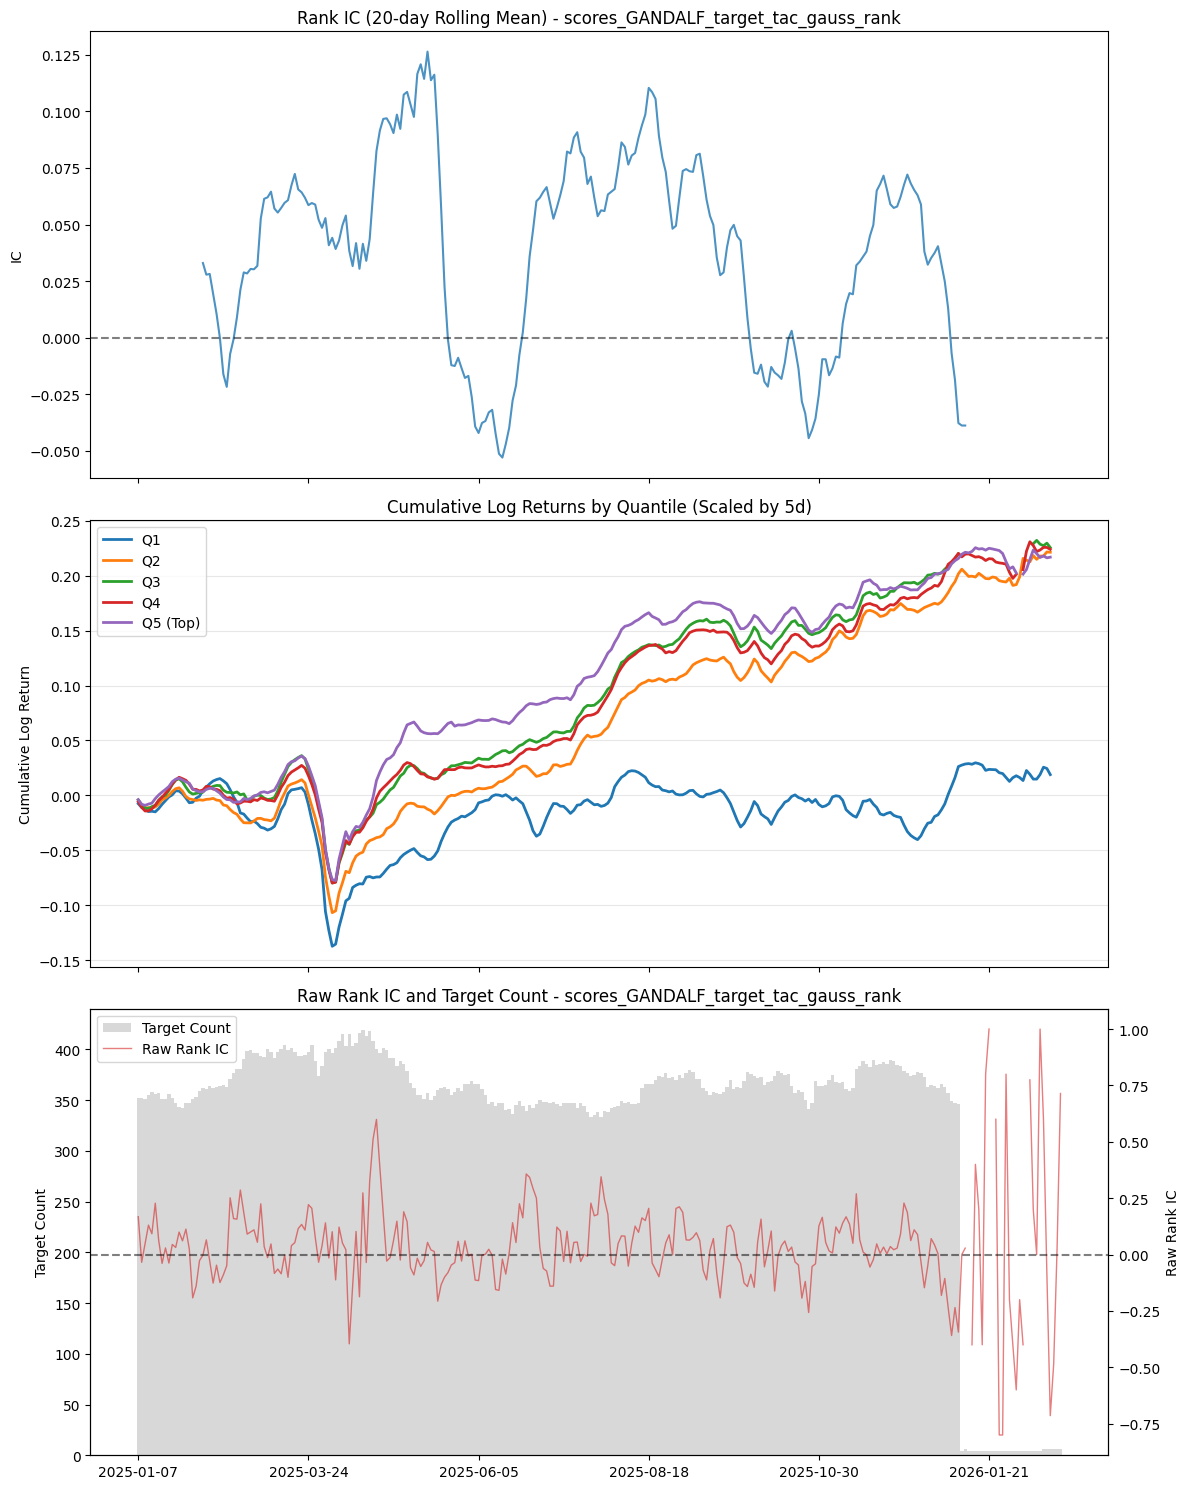

📊 Calculating Rank IC for scores_LightGBM_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1031
  ICIR:    0.3825
  t-stat:  6.3078 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_tac_gauss_rank.png


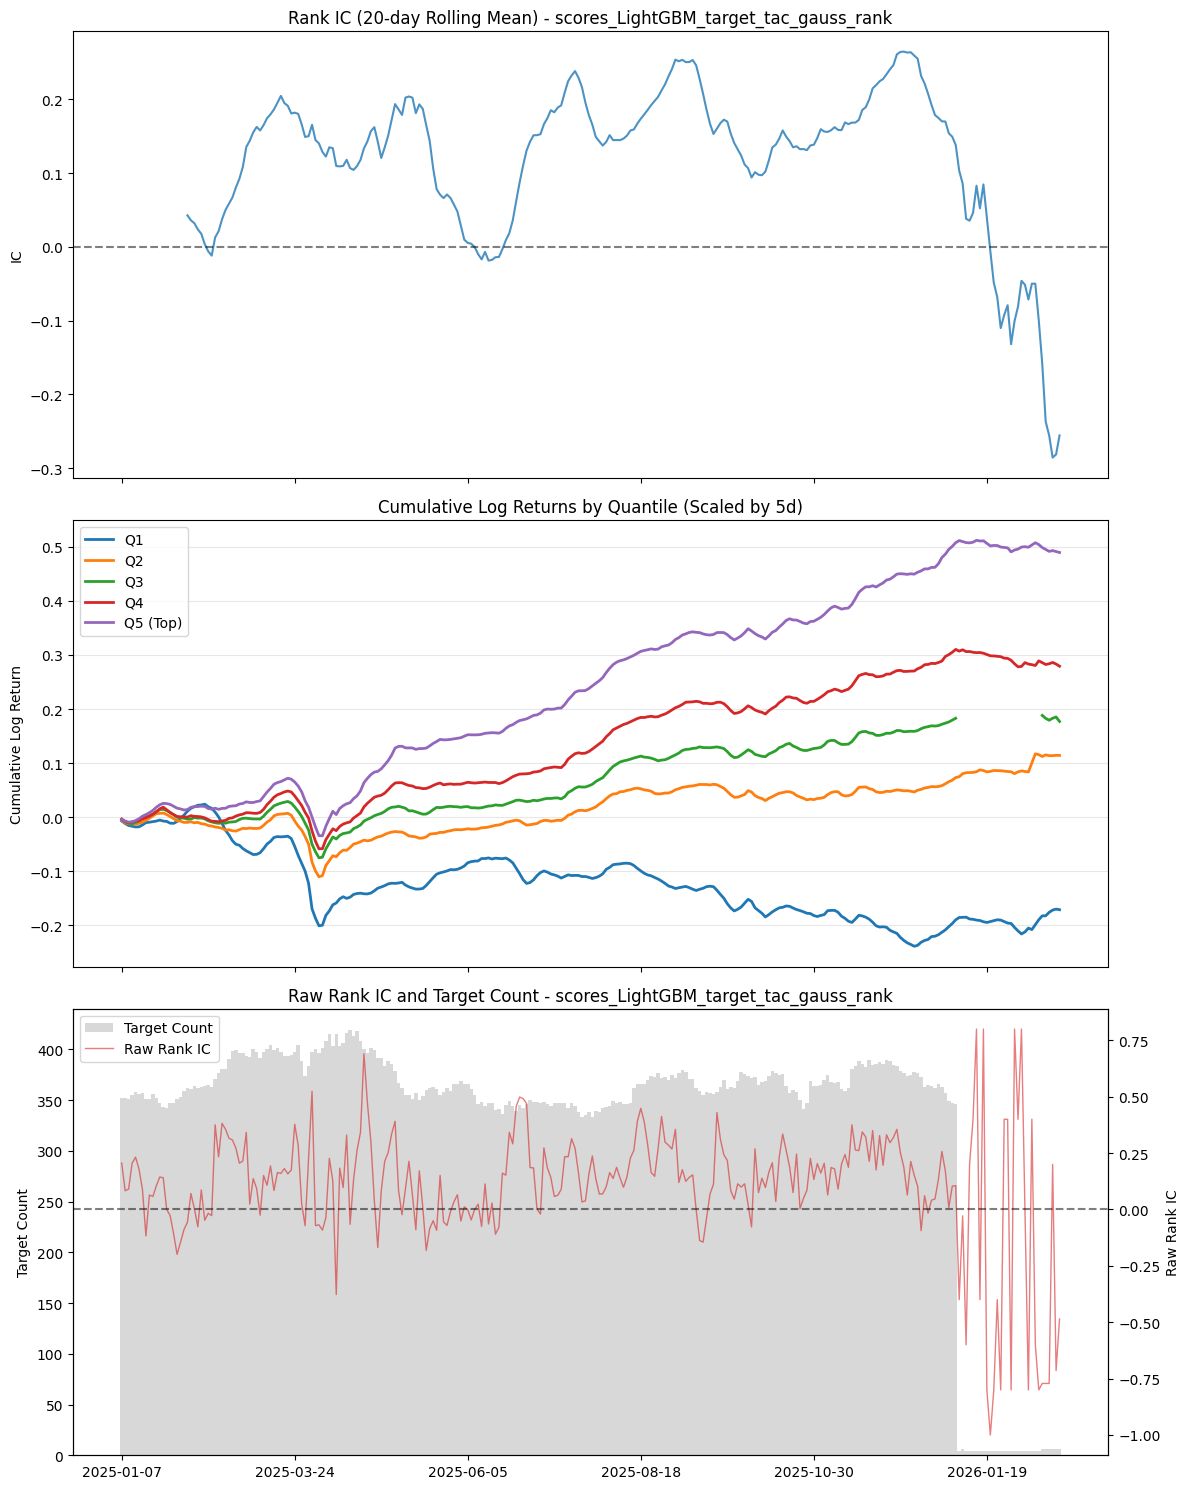

📊 Calculating Rank IC for scores_LightGBM_target_tac_tb_strategy_a...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0545
  ICIR:    0.2542
  t-stat:  4.1928 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_tac_tb_strategy_a.png


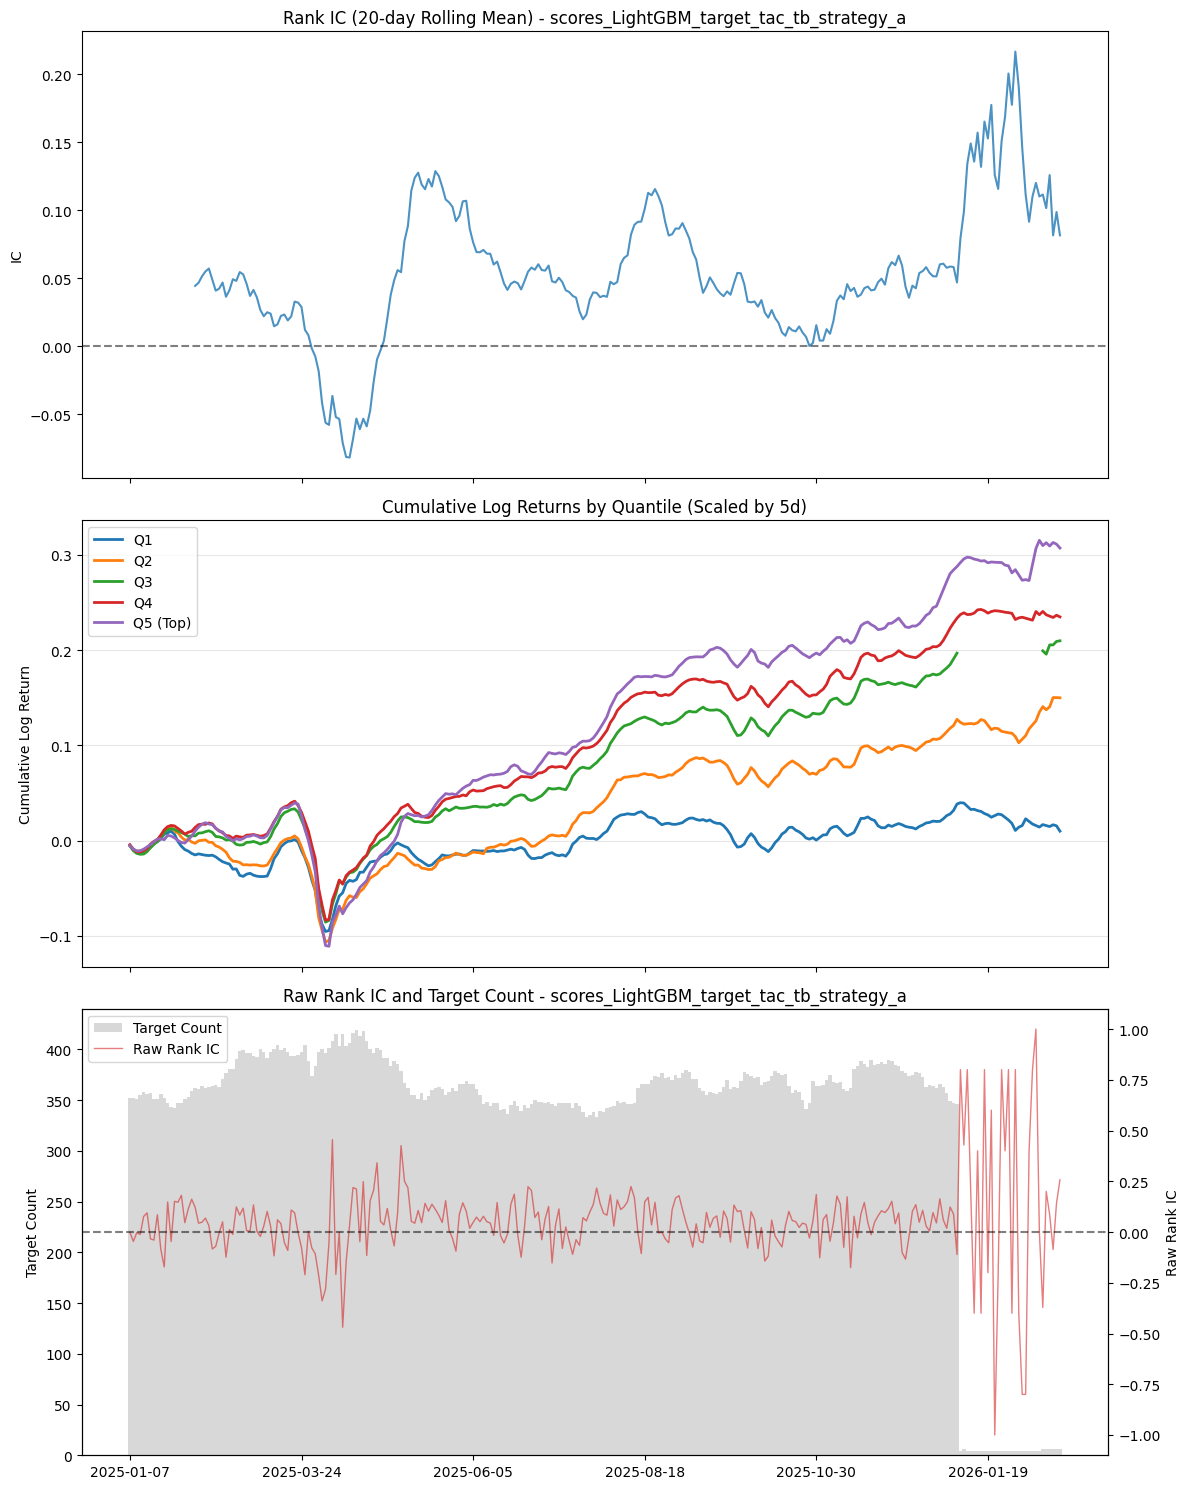

📊 Calculating Rank IC for scores_TCN_target_tac_vol_scaled_residual...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0449
  ICIR:    0.1924
  t-stat:  3.1725 (p-value: 0.0017)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_TCN_target_tac_vol_scaled_residual.png


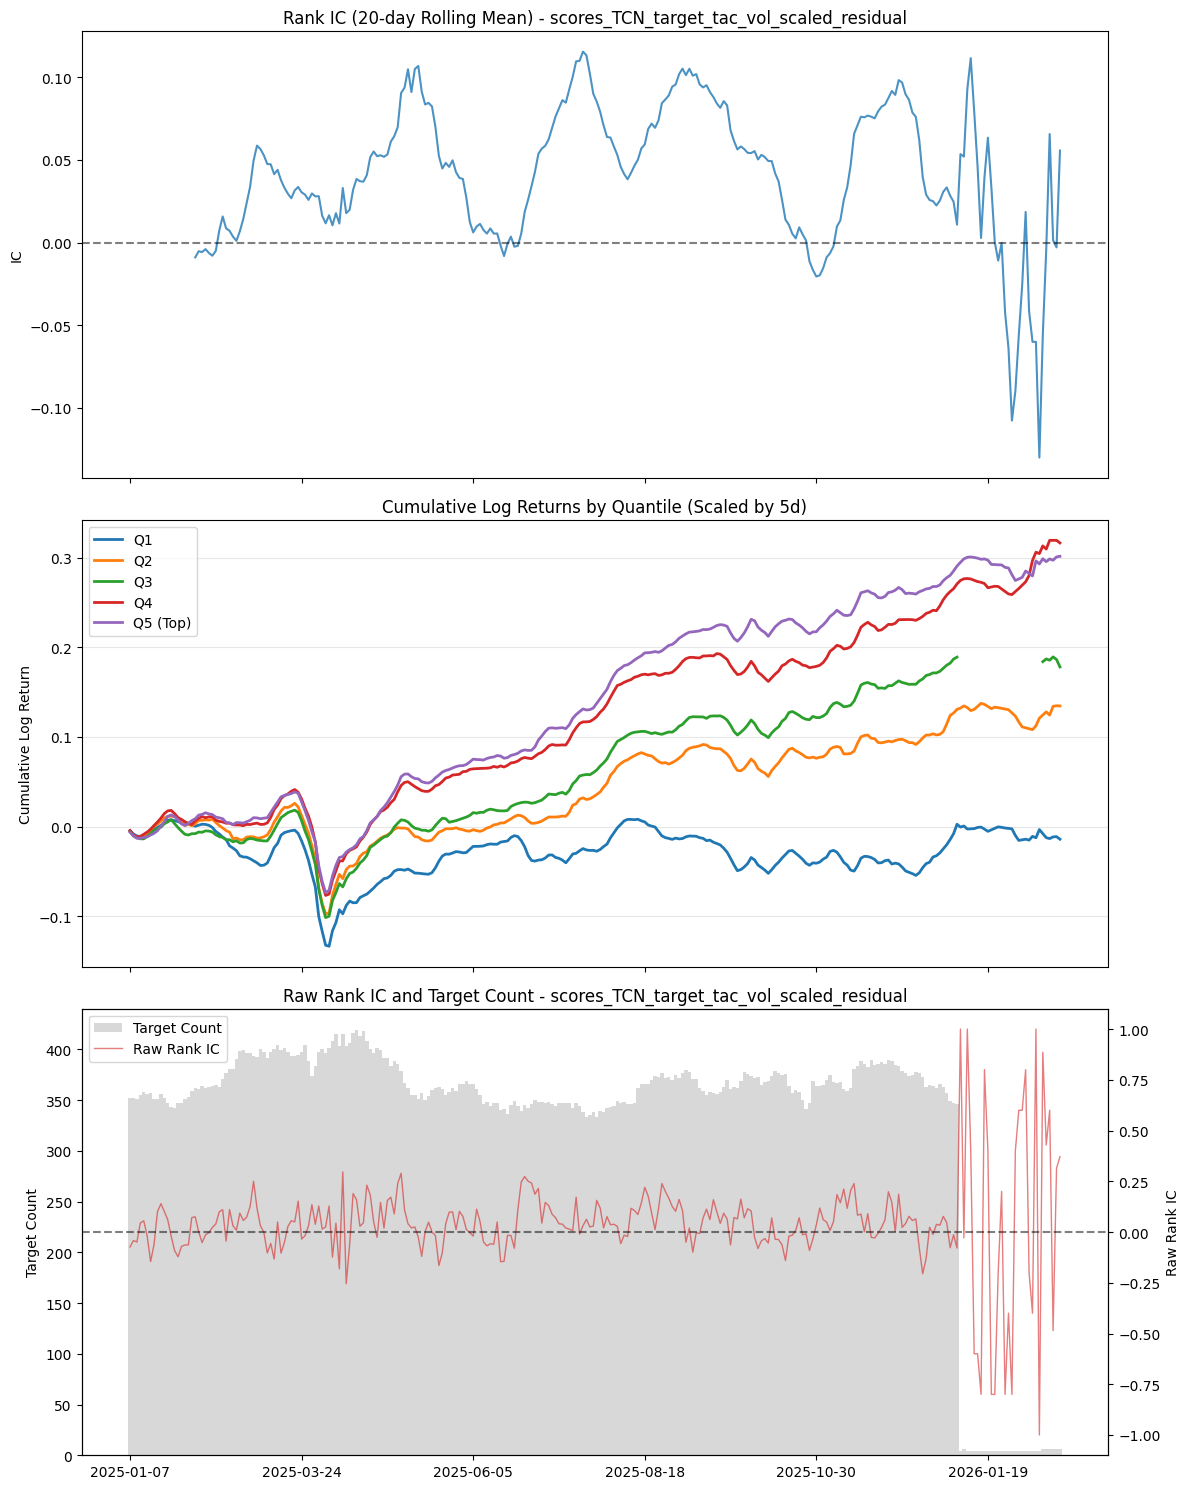

📊 Calculating Rank IC for scores_TabNet_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.0282
  ICIR:    0.1106
  t-stat:  1.8249 (p-value: 0.0691)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_TabNet_target_tac_gauss_rank.png


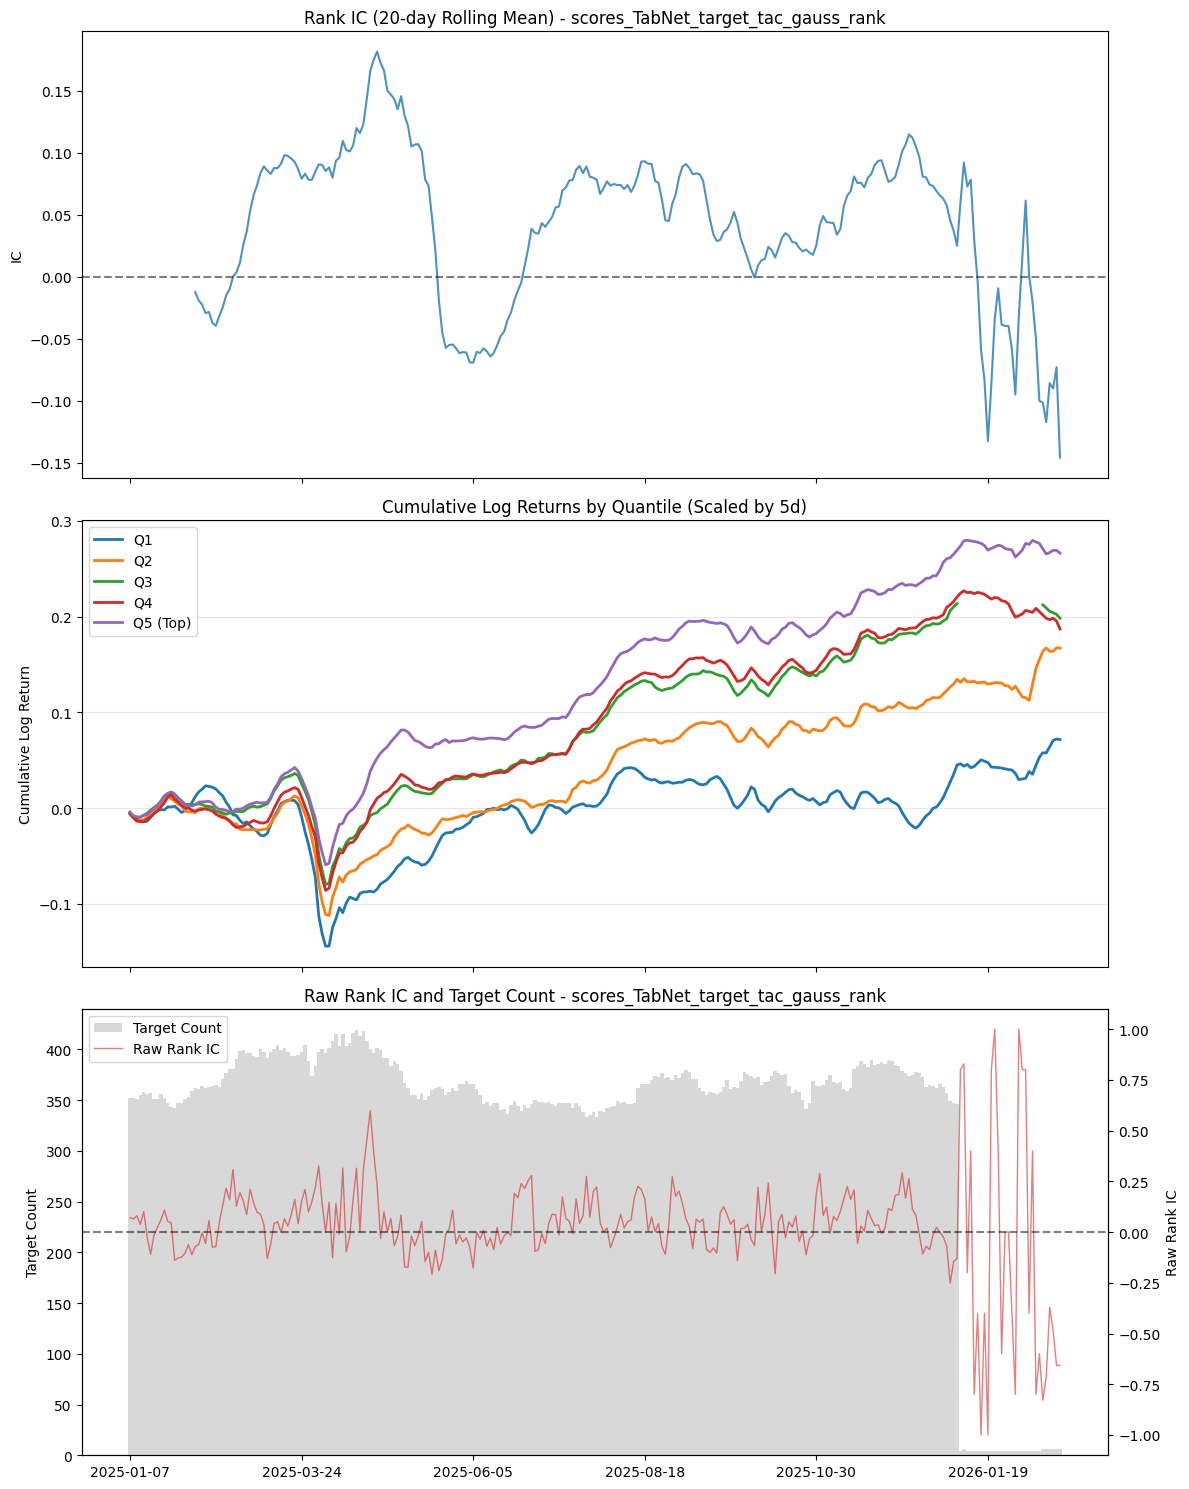

📊 Calculating Rank IC for scores_GANDALF_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1745
  ICIR:    1.0847
  t-stat:  17.8900 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_GANDALF_target_str_gauss_rank.png


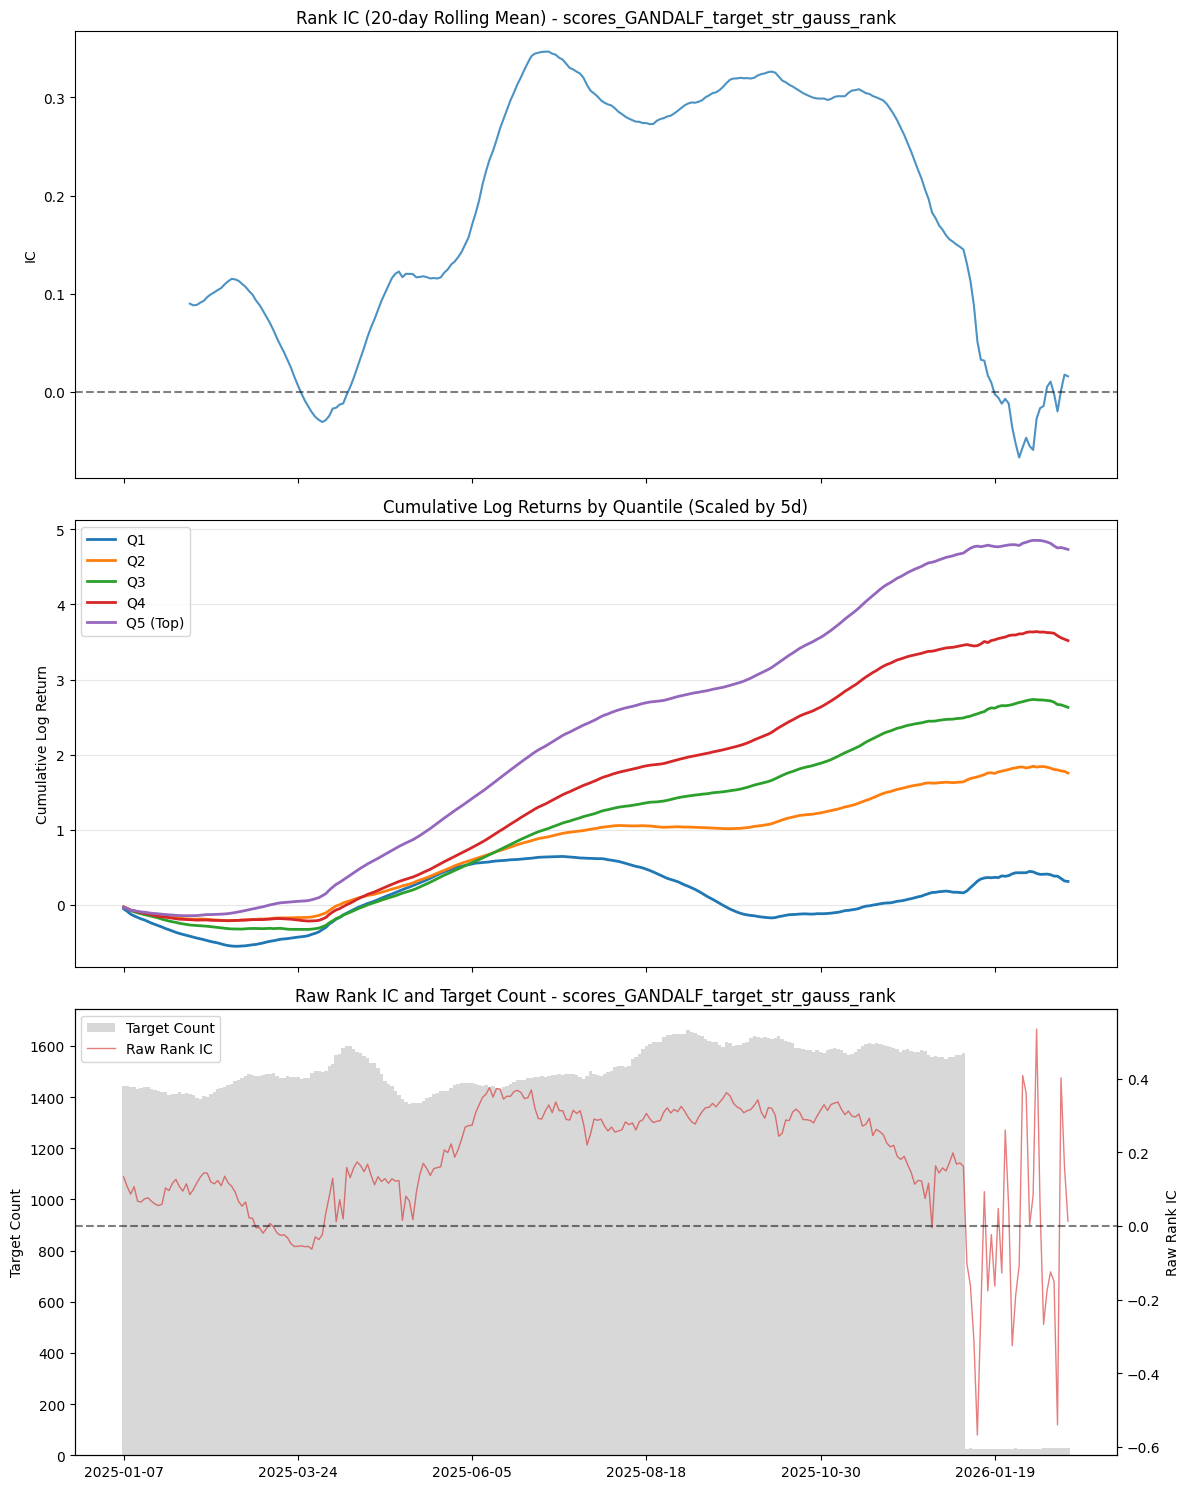

📊 Calculating Rank IC for scores_LightGBM_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.2638
  ICIR:    1.5376
  t-stat:  25.3589 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_str_gauss_rank.png


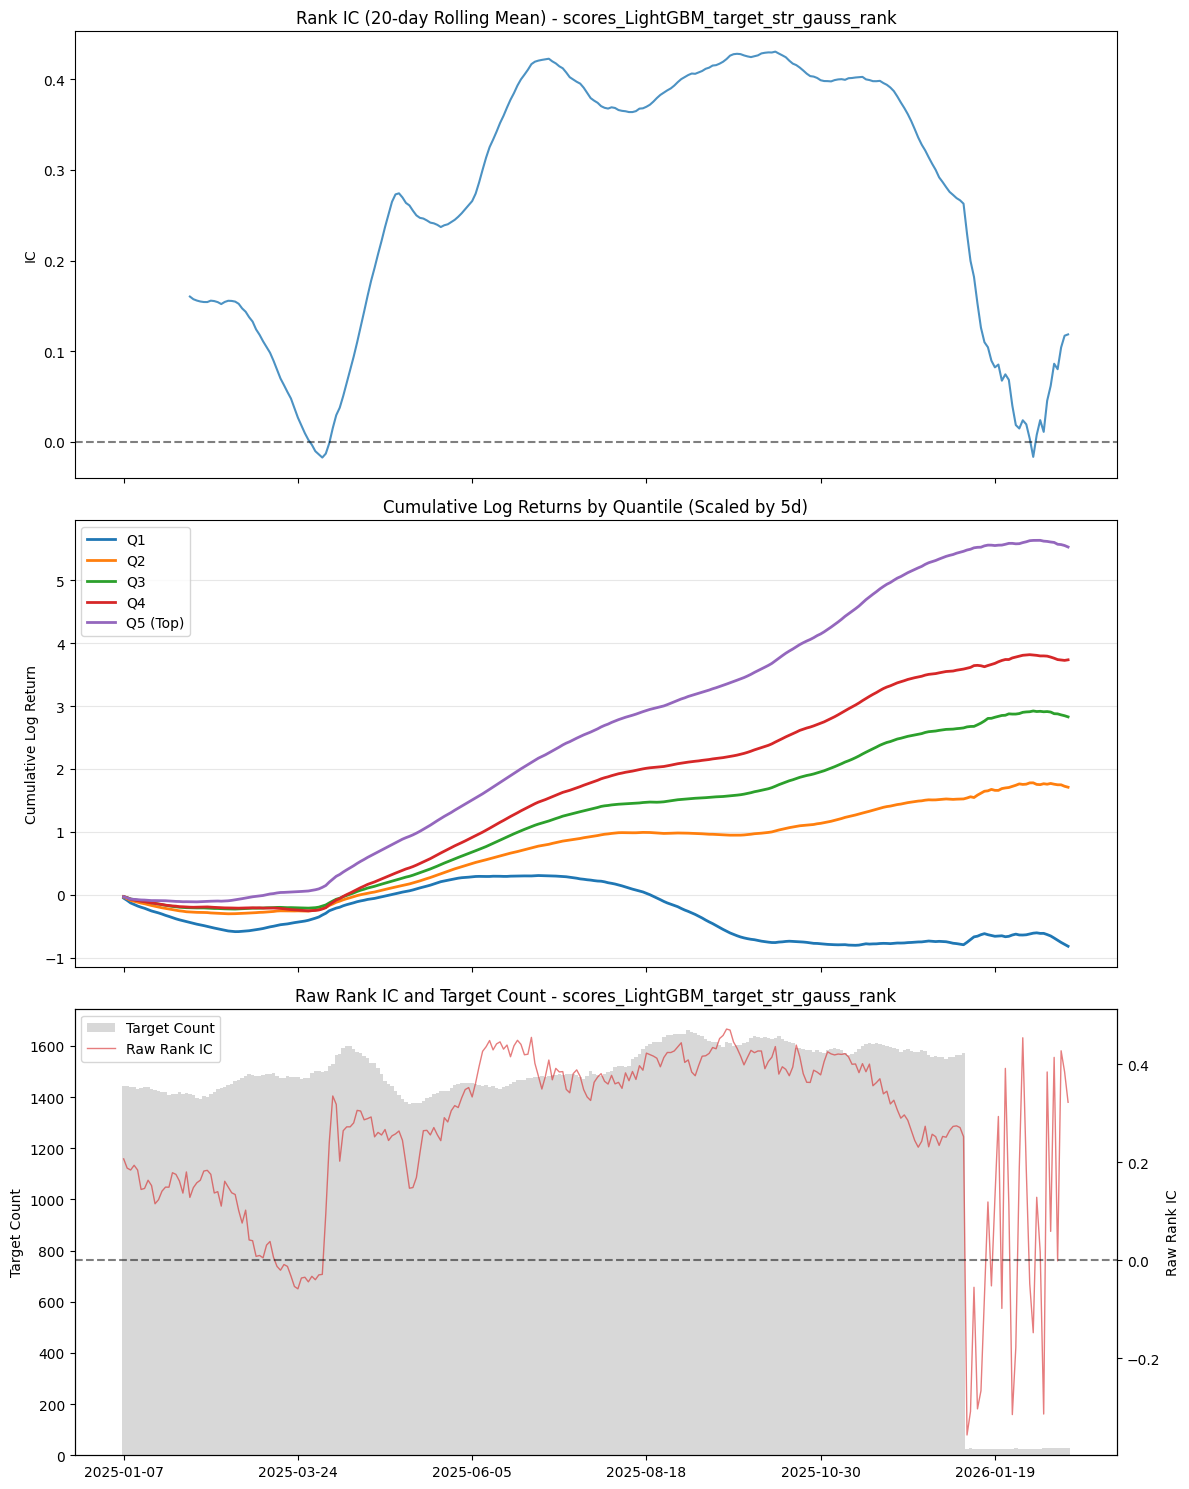

📊 Calculating Rank IC for scores_LightGBM_target_str_triple_barrier...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1955
  ICIR:    1.0921
  t-stat:  18.0112 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_str_triple_barrier.png


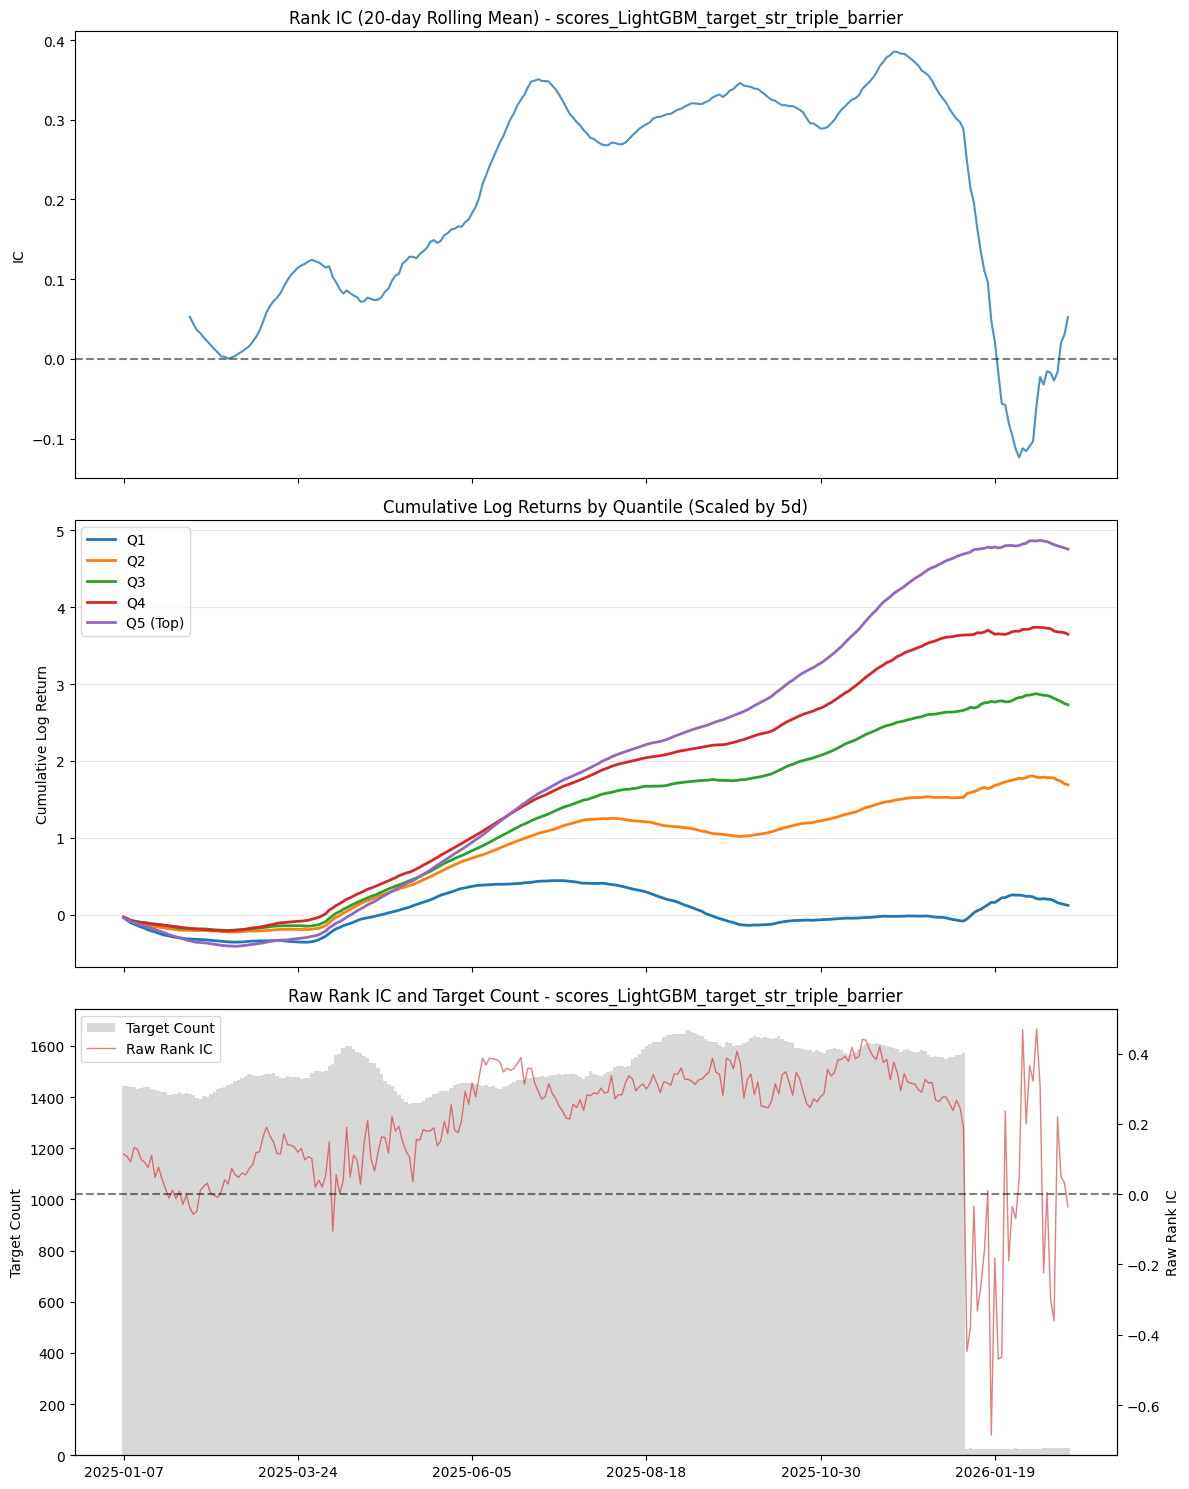

📊 Calculating Rank IC for scores_TabNet_target_str_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1673
  ICIR:    1.1502
  t-stat:  18.9704 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_TabNet_target_str_gauss_rank.png


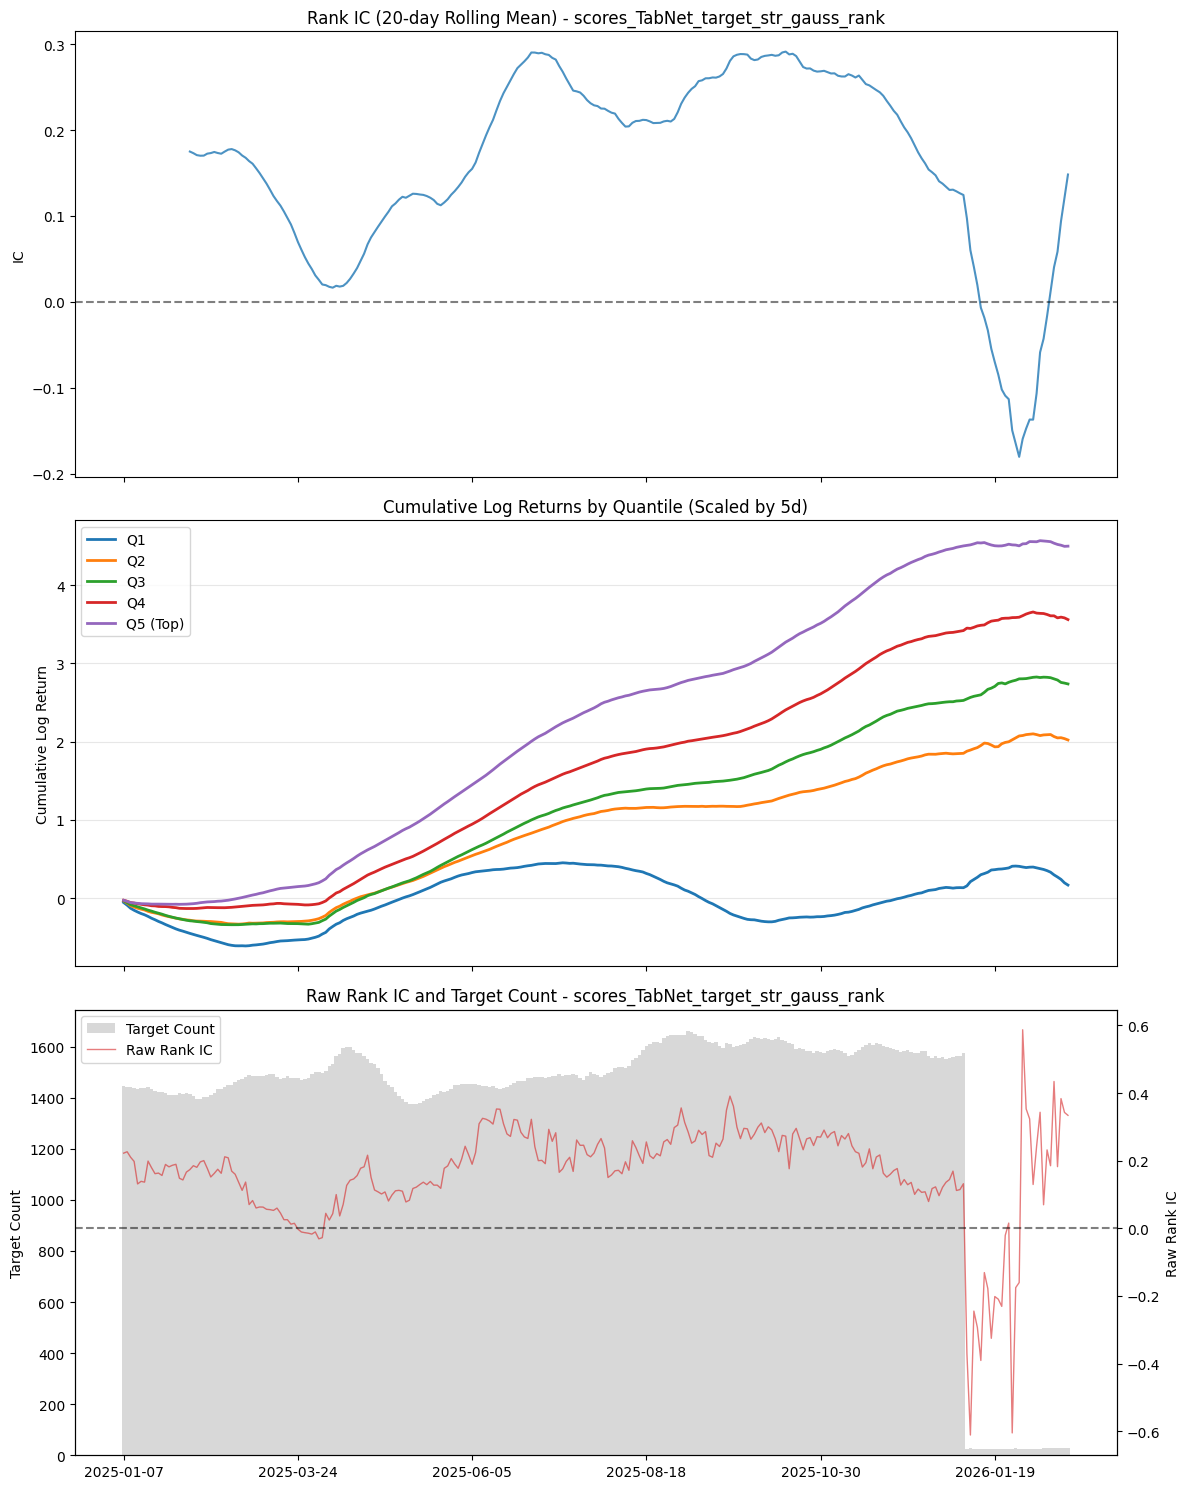

In [32]:
scores_tac = [x for x in df.columns if x.find('scores_')!=-1 and x.find('_tac_')!=-1]
scores_str = [x for x in df.columns if x.find('scores_')!=-1 and x.find('_str_')!=-1]

for score in scores_tac: 
    res = evaluate_model_performance(
        df, 
        score_col=score,
        target_col='Future_Close_Tac', 
        horizon=5,
        save_dir='./evaluation_plots'
    )
    res.to_csv('results_'+score+'.csv',index=False)

for score in scores_str: 
    res = evaluate_model_performance(
        df, 
        score_col=score,
        target_col='Future_Close_Str', 
        horizon=5,
        save_dir='./evaluation_plots'
    )
    res.to_csv('results_'+score+'.csv',index=False)

📊 Calculating Rank IC for scores_LightGBM_target_tac_gauss_rank...


/var/folders/jk/b5tnwh1j1hq90nsy6xg8w2_h0000gn/T/ipykernel_826/2119196419.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = df.groupby('date').apply(calc_daily_ic)


  Mean IC: 0.1031
  ICIR:    0.3825
  t-stat:  6.3078 (p-value: 0.0000)
📈 Calculating Quantile Analysis (bins=5)...
✅ Plot saved to ./evaluation_plots/evaluation_scores_LightGBM_target_tac_gauss_rank.png


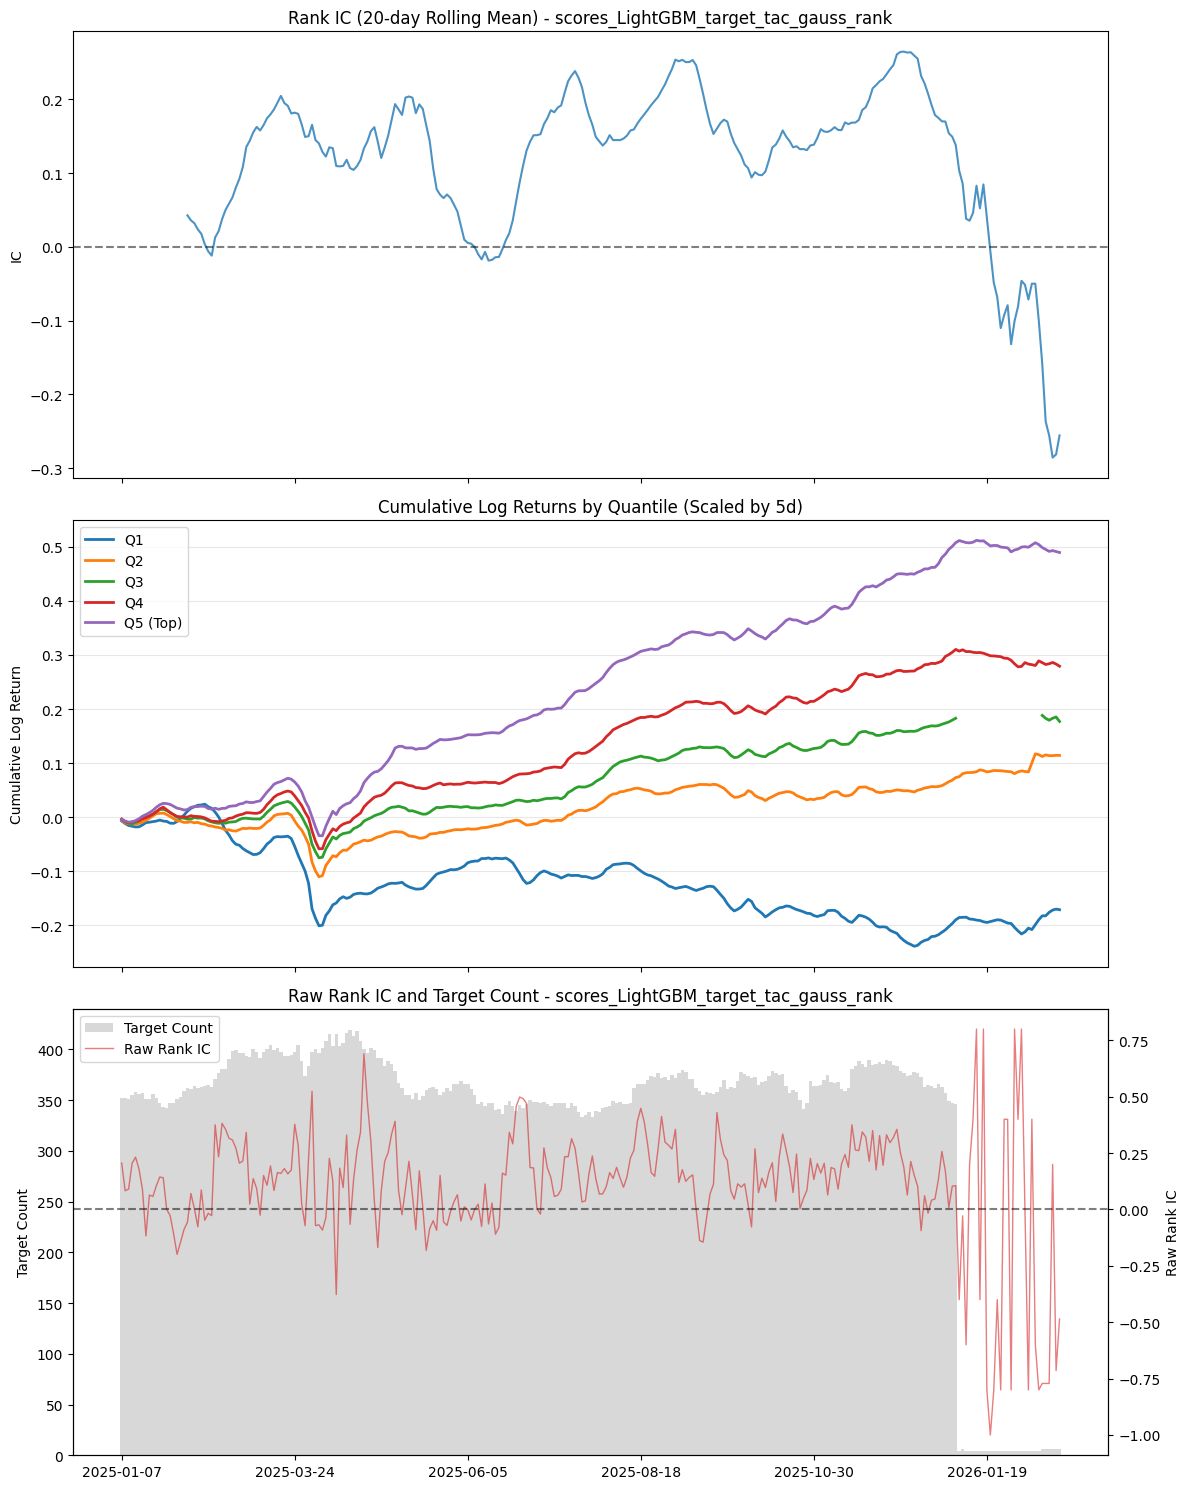

In [28]:
res = evaluate_model_performance(
    df, 
    score_col='scores_LightGBM_target_tac_gauss_rank', 
    target_col='Future_Close_Tac', 
    horizon=5,
    save_dir='./evaluation_plots'
)

In [23]:
res


,date,target_count,daily_ic,cum_log_ret_Q1,cum_log_ret_Q2,cum_log_ret_Q3,cum_log_ret_Q4,cum_log_ret_Q5
0,2025-01-07,1444,0.145160,-0.006936,-0.006362,-0.004610,-0.004377,-0.004515
1,2025-01-08,1443,0.098960,-0.012799,-0.011160,-0.008489,-0.008368,-0.008038
2,2025-01-09,1441,0.174904,-0.017381,-0.014369,-0.010770,-0.010432,-0.009335
3,2025-01-10,1438,0.162164,-0.018830,-0.014658,-0.010909,-0.010111,-0.008247
4,2025-01-14,1433,0.091931,-0.018582,-0.013103,-0.009755,-0.008585,-0.006194
...,...,...,...,...,...,...,...,...
267,2026-02-12,28,-0.461412,-0.052535,0.082693,0.205796,0.291428,0.422446
268,2026-02-13,28,-0.251779,-0.045542,0.089449,0.194602,0.289477,0.431846
269,2026-02-16,28,-0.180624,-0.042719,0.081891,0.199437,0.292922,0.429782
270,2026-02-17,28,0.077460,-0.061610,0.084408,0.202285,0.294143,0.424872
